# YZ50 — Week 3: Language Modeling

- A **bigram character model** predicts the probability of the next character based only on the current character.

- The model can be built by **counting how often character pairs occur** and converting these counts into probability distributions.

- **Negative Log Likelihood (NLL)** is used to measure how well the model predicts the actual next characters. A lower NLL means the model assigns higher probabilities to the correct predictions.

- The same bigram model can also be learned with a **single-layer neural network** using one-hot encoded inputs, logits, softmax, and gradient descent.

In this week, the bigram model is first built using **counting** and then learned using a **neural network**, showing that both approaches can learn the same probability distribution.

# Building a Makemore (Character Level Language Model)

# 1. Karpathy'nin İngilizce names.txt dosyasıyla başla, Türkçe veri görev 5'te gelecek. Bigram'ları önce Python dictionary ile, sonra 27x27 torch tensor'da say. Tabloyu videodaki gibi görselleştir.

In [1037]:
words = open("names.txt").read().splitlines() # Read the names from the file and split them into a list

In [1038]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [1039]:
len(words)

32033

In [1040]:
min(len(w) for w in words)

2

In [1041]:
max(len(w) for w in words)

15

- A **character level language model** is predicting the next character given in a sequence of characters. For example, given the sequence "Ediz", the model should predict the next character " " (space) or "A" (if the name is "Ediz Arkın").

## Bigram Character Model

- in bigram language model we always working with just two characters at a time, we are looking only one character that given and we try to predict next character in a sequence

A **character-level bigram** is a pair of consecutive characters in a text sequence.

A bigram language model learns the probability of the **next character given the current character**.

For example, for the name `emma`:

`<e> → <m>`  
`<m> → <m>`  
`<m> → <a>`  
`<a> → <.>`

The model therefore learns probabilities of the form:

\[
P(c_{t+1} \mid c_t)
\]

where \(c_t\) is the current character and \(c_{t+1}\) is the next character.

## Python Dictionary

In [1042]:
b = {} # Initialize an empty dictionary to store bigram counts
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] # Add start and end tokens to the word
    for ch1, ch2 in zip(chs, chs[1:]): # Iterate through each character in the word and its next character
        bigram = (ch1, ch2) # Create a bigram tuple
        b[bigram] = b.get(bigram, 0) + 1 # Increment the count of the bigram in the dictionary

In [1043]:
sorted(b.items(), key = lambda kv: kv[1], reverse=True)[:10] # Sort the bigrams by their counts in descending order and display the top 10 most frequent bigrams

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

In [1044]:
import torch

a = torch.zeros((3, 5), dtype=torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [1045]:
# a[row,column] = value
a[1,4] = 1 # Set the element at row 1, column 4 to 1
a[0,0] = 5 # Set the element at row 0, column 0 to 5

In [1046]:
a

tensor([[5, 0, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

## 27x27 Tensors

In [1047]:
N = torch.zeros((27, 27), dtype=torch.int32) # Initialize a 27x27 matrix to store bigram counts (26 letters + 1 for start/end tokens)

In [1048]:
# Create a lookup table to map characters to indices (0-25 for 'a'-'z', 26 for start/end tokens)
chars = sorted(list(set(''.join(words)))) # Create a sorted list of unique characters in the words
stoi = {s:i+1 for i,s in enumerate(chars)} # Create a dictionary to map characters to their corresponding indices
stoi['.'] = 0 # Add a mapping for the start/end token to index 0
itos = {i:s for s,i in stoi.items()} # Create a reverse lookup table to map indices back to characters

In [1049]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [1050]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [1051]:
for w in words:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] # Get the index of the first character in the bigram
        ix2 = stoi[ch2] # Get the index of the second character in the bigram
        N[ix1, ix2] += 1 # Increment the count of the bigram in the matrix

In [1052]:
type(N[3, 5]) # returns tensor type

torch.Tensor

In [1053]:
type(N[3, 5].item()) # returns the type of the value in the tensor, which is a Python int

int

## Virtualization (Counts array of entire dataset)

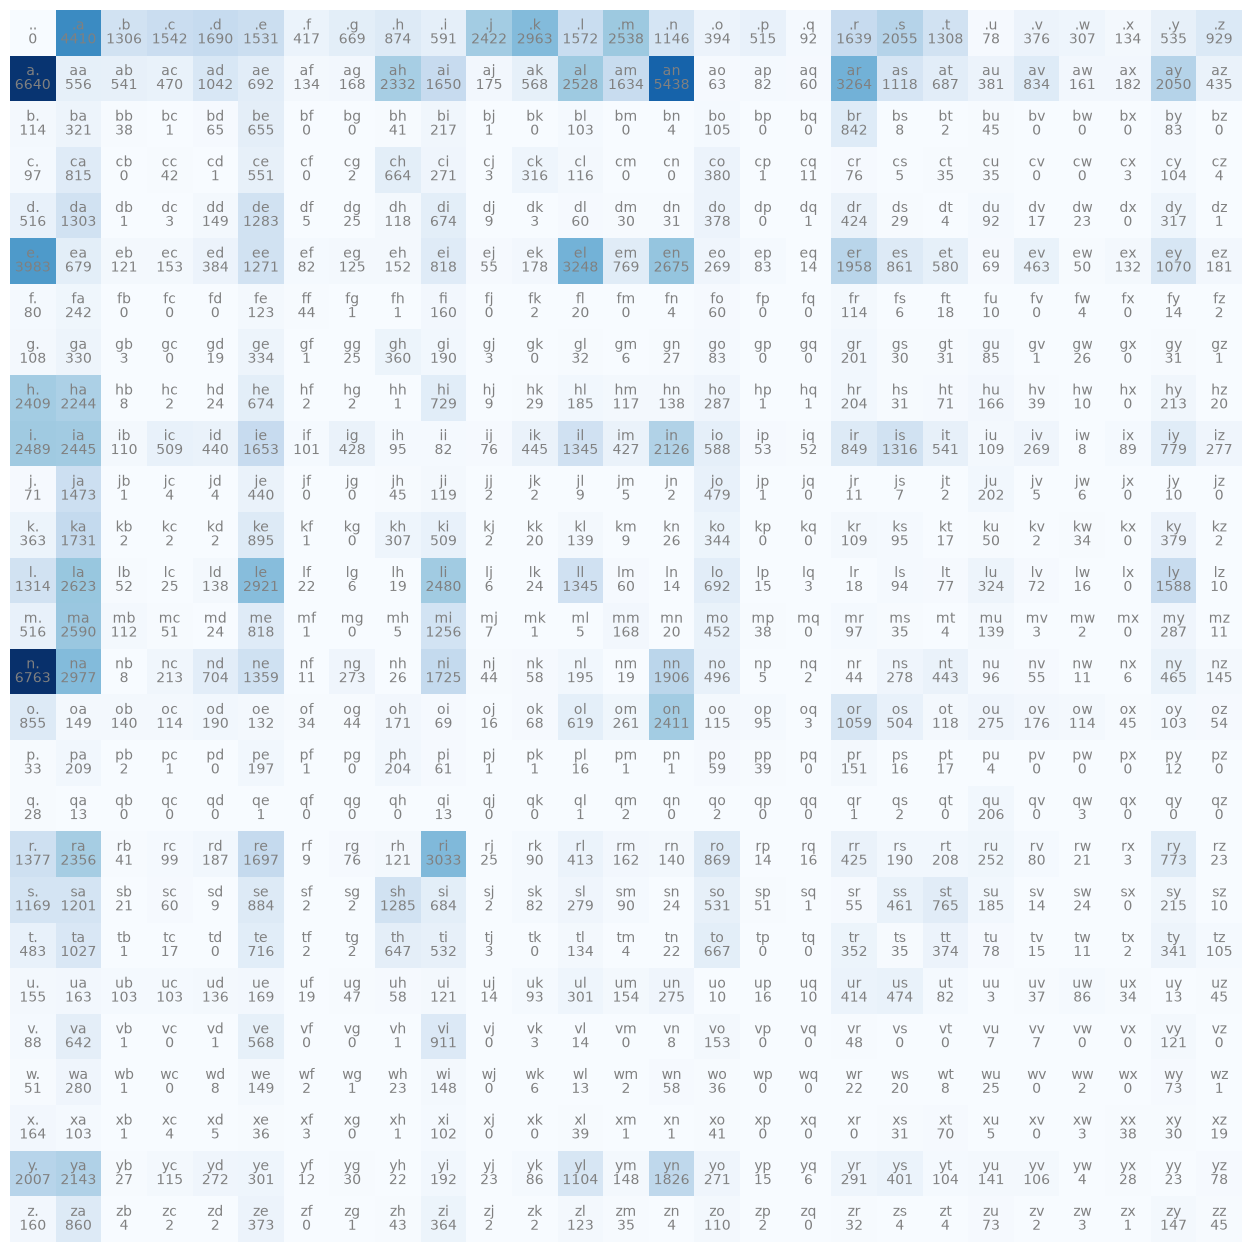

In [1054]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

# 2. Sayım tablosunu satır satır olasılıklara çevir ve modelden yeni isimler örnekle. Broadcasting'e dikkat: videodaki keepdim tuzağı, sessizce yanlış model üreten cinsten.

In [1055]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

## Convert the raw numbers into probabilities

In [1056]:
p = N[0].float() # Convert the counts to float for probability calculations
p = p / p.sum() # Normalize the counts to get probabilities
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [1057]:
p.sum()

tensor(1.)

In [1058]:
g = torch.Generator().manual_seed(2147483647) # Create a random number generator with a fixed seed for reproducibility
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # Sample one index from the probability distribution defined by p
ix # Look up the corresponding character in the itos dictionary using the sampled index

3

In [1059]:
itos[ix]

'c'

* creating random names

In [1060]:
P = (N+1).float() # Convert the counts to float for probability calculations AND add 1 to each count for Laplace smoothing (to avoid zero probabilities for unseen bigrams)
P /= P.sum(1, keepdim=True) # Normalize the counts to get probabilities for each row

In [1061]:
P[0].sum()

tensor(1.)

`P = N.float()` converts the count matrix `N` from integers to floating-point numbers so that we can perform probability calculations. Then, `P.sum(1, keepdim=True)` calculates the sum of each row independently. Dividing `P` by these row sums normalizes each row so that its values add up to `1`. As a result, each row becomes a probability distribution representing the **probability of the next character given the current character**, i.e. `P(next character | current character)`.

Here, **broadcasting** allows PyTorch to automatically expand a smaller tensor to match the shape of a larger tensor during an element-wise operation. In our example, `P` has shape `(27, 27)`. To correctly divide `P` by its row sums, we need to pay close attention to the tensor dimensions.

### The Importance of `keepdim=True`

When we calculate:

```python
P.sum(1, keepdim=True)
```

the `1` means that we sum along the columns, so we get the sum of each row.

Without `keepdim=True`:

```python
P.sum(1).shape
# (27,)
```

The 2D tensor `(27, 27)` becomes a 1D tensor `(27,)`. PyTorch can still perform broadcasting when dividing:

```python
P / P.sum(1)
```

but the `(27,)` tensor is aligned with the last dimension, meaning the values are treated as column-wise values rather than row-wise sums. This is not what we want. 

Here is what happens visually without `keepdim=True`:

P:
```text
[ a₁  a₂  a₃ ... a₂₇ ]
[ b₁  b₂  b₃ ... b₂₇ ]
[ c₁  c₂  c₃ ... c₂₇ ]
        .
        .
        .
```

sum:
```text
[ s₁  s₂  s₃ ... s₂₇ ]
```

Broadcasting:
```text
[ a₁/s₁  a₂/s₂  a₃/s₃ ... ]
[ b₁/s₁  b₂/s₂  b₃/s₃ ... ]
[ c₁/s₁  c₂/s₂  c₃/s₃ ... ]
        .
        .
        .
```

With `keepdim=True`:

```python
P.sum(1, keepdim=True).shape
# (27, 1)
```

the result remains 2D. Now the division becomes:

`(27, 27) / (27, 1)`

Through broadcasting, each row's sum is expanded across all columns of that same row:

```text
[ a₁  a₂  a₃ ... ] / s₁
[ b₁  b₂  b₃ ... ] / s₂
[ c₁  c₂  c₃ ... ] / s₃
```

For example, with a 3x3 tensor:

```text
[2, 0,  8] / [10]
[4, 4, 12] / [20]
[6, 9, 15] / [30]
```

this is treated as:

```text
[2, 0,  8] / [10, 10, 10]
[4, 4, 12] / [20, 20, 20]
[6, 9, 15] / [30, 30, 30]
```

resulting in:

```text
[0.2, 0.0, 0.8]
[0.2, 0.2, 0.6]
[0.2, 0.3, 0.5]
```

Therefore, broadcasting allows each row to be divided by its own row sum automatically, making each row a valid probability distribution whose values sum to 1.

So, `keepdim=True` is critical here because it preserves the dimension needed for broadcasting to normalize each row independently.


## Summary

### Broadcasting: Why We Must Use `keepdim=True`

When dividing a matrix by its row sums in PyTorch, we must pay close attention to how broadcasting rules align the tensor dimensions.

*   **WITHOUT `keepdim=True` (The Wrong Approach):**
    *   The sum operation leaves us with a 1D horizontal array of shape `(27,)`.
    *   To make this compatible with the original `(27, 27)` matrix during division, PyTorch's broadcasting mechanism copies this horizontal array **downwards (row by row)**.
    *   As a result, each element is divided by the sum corresponding to its column index rather than its own row sum, completely breaking the mathematical logic.

*   **WITH `keepdim=True` (The Correct Approach):**
    *   The sum operation leaves us with a 2D vertical column vector of shape `(27, 1)`.
    *   To make this compatible with the original matrix, PyTorch's broadcasting mechanism copies this vertical column 27 times **horizontally (to the right)**.
    *   This way, through element-wise division, all elements in a given row are perfectly divided by that specific row's sum, yielding the correct probability distribution.

In [1062]:
ix = 0
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    while True:

        p = P[ix]

        #p = N[ix].float() # Get the counts for the current character and convert to float
        #p = p / p.sum() # Normalize the counts to get probabilities


        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # Sample one index from the probability distribution defined by p
        out.append(itos[ix]) # Append the corresponding character to the output list
        if ix == 0: # If the sampled index is 0 (start/end token), break the loop
            break
    print(''.join(out)) # Join the characters in the output list to form a string and print it

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


# 3. Negative log likelihood'u hesapla. Smoothing için sahte sayım ekle. Neden log, neden negatif, neden ortalama

## Likelihood Concepts in Statistical Models

In machine learning and statistical modeling, three fundamental concepts are used sequentially to measure the quality of a model, how well it has learned from the data, and to train it: **Likelihood**, **Log-Likelihood**, and **Negative Log-Likelihood**.

---

### 1. Likelihood

*   **What is it?** 
    Given a model with a specific set of parameters $\theta$, the likelihood is the **probability of observing the actual data** $x$ we have. For an entire dataset, the overall likelihood is calculated as the **product of all the individual probabilities** of each observation. It is mathematically represented as:
    $$\mathcal{L}(\theta \mid x) = \prod_{i=1}^{n} P(x_i \mid \theta)$$
*   **Why is it used?** 
    It is used as a "scoring system" to measure how well the model explains the observed real-world data or how successfully it makes predictions. The higher the likelihood, the better the model.
*   **Where is it used?** 
    It is used in fundamental statistical analysis, in determining the parameters of probability distributions, and in expressing the overall success rate of a model (such as a language model predicting the next character based on previous characters).

---

### 2. Log-Likelihood

*   **What is it?** 
    It is simply the natural logarithm of the Likelihood value, represented as:
    $$\log \mathcal{L}(\theta \mid x)$$
*   **Why is it used?** 
    As mentioned above, to find the total likelihood of an entire dataset, we need to **multiply** (take the product of) the individual probabilities of each data point. Because probabilities are numbers between $0$ and $1$, multiplying thousands of them together results in an incredibly small number. Computers cannot hold such tiny values in memory and will round them to zero (a problem known as **floating-point underflow**). 
    Applying a logarithm transforms these multiplication operations into addition:
    $$\log(a \cdot b) = \log(a) + \log(b)$$
    This prevents the underflow error and makes taking derivatives and performing computations significantly easier for algorithms.
*   **Where is it used?** 
    It is heavily used in Maximum Likelihood Estimation (MLE) algorithms to compute the model's performance score in a much more mathematically stable way.

---

### 3. Negative Log-Likelihood (NLL)

*   **What is it?** 
    It is the Log-Likelihood value multiplied by negative one ($-1$), expressed as:
    $$-\log \mathcal{L}(\theta \mid x)$$
*   **Why is it used?** 
    Optimization algorithms used in machine learning and deep learning frameworks (like PyTorch or TensorFlow, e.g., Gradient Descent) are inherently designed to **minimize a value** (bring it closer to zero) rather than maximize it. 
    Our ultimate goal is to maximize the likelihood (the model's success). Mathematically, "maximizing the Log-Likelihood" is exactly the same operation as "minimizing the Negative Log-Likelihood". By flipping the sign to negative, we convert the score into a standard objective to minimize.
*   **The Average NLL as a Loss Function:** 
    While the NLL gives us the total error, in practice, we use the **average** of the Negative Log-Likelihood across all training examples (or a mini-batch) as the final **Loss Function**. Mathematically, this is expressed as:
    $$\text{Loss} = -\frac{1}{n} \sum_{i=1}^{n} \log P(x_i \mid \theta)$$
    **Why use the average?**
    *   **Batch Size Independence:** If we simply summed the NLL, the total loss value would grow larger as the dataset or batch size grows. Averaging normalizes the loss, making its magnitude independent of how many examples we are processing at once.
    *   **Stable Learning Rates:** Because the loss (and consequently, the calculated gradients) remains on a similar scale regardless of the batch size, we can use a consistent learning rate during optimization. If we used the sum instead, a larger batch would produce a massive gradient, forcing us to constantly retune the learning rate to prevent the model from becoming unstable.
*   **Where is it used?** 
    It is directly used to calculate the loss value when training neural networks in classification problems (like image recognition or character prediction). It forms the absolute core of the famous **Cross-Entropy Loss** function in PyTorch.

In [1063]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [1064]:
log_likelihood = 0.0
n = 0;

for w in words:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f"{ch1}{ch2}: {prob:.4f} ({logprob:.4f})")
print(f"Log-likelihood: {log_likelihood:.4f}")
nll = -log_likelihood
print(f"Negative Log-likelihood: {nll:.4f}")
print(f"Number of tokens: {n}")
print(f"Average negative log-likelihood: {nll/n:.4f}") # our loss function is the Average negative log-likelihood, which we want to minimize during training (0--to--infinity)

Log-likelihood: -559951.5625
Negative Log-likelihood: 559951.5625
Number of tokens: 228146
Average negative log-likelihood: 2.4544


In [1065]:
def zero_probabiliyt_test():
    P = (N).float()
    P /= P.sum(1, keepdim=True)
    log_likelihood = 0.0
    n = 0;

    for w in ["andrejq"]:
        chs = ['.'] + list(w) + ['.'] 
        for ch1, ch2 in zip(chs, chs[1:]):
            ix1 = stoi[ch1]
            ix2 = stoi[ch2]
            prob = P[ix1, ix2]
            logprob = torch.log(prob)
            log_likelihood += logprob
            n += 1
            print(f"{ch1}{ch2}: {prob:.4f} ({logprob:.4f})")
    print(f"Log-likelihood: {log_likelihood:.4f}")
    nll = -log_likelihood
    print(f"Negative Log-likelihood: {nll:.4f}")
    print(f"Number of tokens: {n}")
    print(f"Average negative log-likelihood: {nll/n:.4f}")

zero_probabiliyt_test()

.a: 0.1377 (-1.9829)
an: 0.1605 (-1.8296)
nd: 0.0384 (-3.2594)
dr: 0.0771 (-2.5620)
re: 0.1336 (-2.0127)
ej: 0.0027 (-5.9171)
jq: 0.0000 (-inf)
q.: 0.1029 (-2.2736)
Log-likelihood: -inf
Negative Log-likelihood: inf
Number of tokens: 8
Average negative log-likelihood: inf


### The Problem of Zero Probability (The Infinity Loss Issue)

When calculating the Negative Log-Likelihood for the word "andrejq", we encounter a critical issue:
```text
jq: 0.0000 (-inf)
Average negative log-likelihood: inf
```
**Why does this happen?** 
The bigram `jq` has never appeared in our training data, meaning its raw count is `0`, which results in a probability of `0.0000`. Because our loss function uses logarithms, calculating $\log(0)$ mathematically evaluates to negative infinity (`-inf`). Since we sum all the log probabilities, a single unseen bigram turns the entire sequence's score into `-inf`, resulting in a final Loss (Average NLL) of `inf`. The model's calculation completely breaks down just because of one unseen character combination.

### The Solution: Model Smoothing (Laplace Smoothing)

To fix this, we use a technique called **Model Smoothing** (specifically, Laplace smoothing). We simply add a small artificial count (usually `1`) to *every* possible bigram combination in our matrix before calculating the probabilities. 

This ensures that even completely unseen bigrams (like `jq`) receive a very small, non-zero probability instead of a hard zero. By eliminating zeros, we avoid the $\log(0)$ trap, and our loss function remains mathematically stable.

Here is how it is implemented:

```python
# Convert the counts to float for probability calculations AND 
# add 1 to each count for Laplace smoothing (to avoid zero probabilities for unseen bigrams)
P = (N+1).float() 

# Normalize the counts to get valid probabilities for each row
P /= P.sum(1, keepdim=True) 
```

In [1066]:
log_likelihood = 0.0
n = 0;

for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f"{ch1}{ch2}: {prob:.4f} ({logprob:.4f})")
print(f"Log-likelihood: {log_likelihood:.4f}")
nll = -log_likelihood
print(f"Negative Log-likelihood: {nll:.4f}")
print(f"Number of tokens: {n}")
print(f"Average negative log-likelihood: {nll/n:.4f}")

.a: 0.1376 (-1.9835)
an: 0.1604 (-1.8302)
nd: 0.0384 (-3.2594)
dr: 0.0770 (-2.5646)
re: 0.1334 (-2.0143)
ej: 0.0027 (-5.9004)
jq: 0.0003 (-7.9817)
q.: 0.0970 (-2.3331)
Log-likelihood: -27.8672
Negative Log-likelihood: 27.8672
Number of tokens: 8
Average negative log-likelihood: 3.4834


# 4. Aynı modeli tek katmanlı sinir ağıyla kur: one-hot input, 27x27 weight matrix, softmax, NLL loss, gradient descent döngüsü. Loss'un görev 3'teki sayım modelinin loss'una yaklaştığını göster. Buradaki backward() geçen hafta micrograd'da kendi yazdığın mekanizmanın aynısı.

### Create the traning set of all bigrams (x,y) where x is the input character and y is the output character

In [1067]:
xs, ys = [], [] # Initialize empty lists to store the input and output indices of the bigrams

for w in words[:1]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(f"{ch1}{ch2}: {ix1} {ix2}")
        xs.append(ix1) # Append the index of the input character to the xs list
        ys.append(ix2) # Append the index of the output character to the ys list

xs = torch.tensor(xs) # Convert the xs list to a PyTorch tensor
ys = torch.tensor(ys) # Convert the ys list to a PyTorch tensor

.e: 0 5
em: 5 13
mm: 13 13
ma: 13 1
a.: 1 0


In [1068]:
xs

tensor([ 0,  5, 13, 13,  1])

In [1069]:
ys

tensor([ 5, 13, 13,  1,  0])

### Apply One-hot Encoding


### Why We Cannot Use Integers Directly as NN Inputs (The Need for One-Hot Encoding)

When processing categorical data like text, we initially map characters to integer indices (e.g., `. = 0`, `a = 1`, `e = 5`, `m = 13`). However, we **cannot feed these integers directly into a neural network**. Here is why:

**1. Integers Imply Order and Magnitude (False Relationships)**
Neural networks treat inputs as mathematical values. If we feed the integers directly, the network will incorrectly assume ordinal relationships between the categories:
*   It will think `13` ('m') is mathematically larger or "stronger" than `5` ('e').
*   It will assume the distance between `1` and `5` is smaller than the distance between `1` and `13`.
*   It might even assume that character `13` is related to character `5` multiplied by some factor. 

In reality, characters are **categorical (nominal) data**. They are distinct classes with no natural numerical order. 'm' is not "greater" than 'e'.

**2. The Weight Multiplication Problem**
In the first layer of a neural network, inputs ($x$) are multiplied by weights ($w$). If we use integer indices as $x$, calculating $w \cdot 13$ yields a vastly different and larger activation than $w \cdot 1$. The network would inherently prioritize or heavily scale characters just because they happen to appear later in the alphabet, completely ruining the learning process.

**3. The Solution: One-Hot Encoding**
To solve this, we use **One-Hot Encoding** (e.g., `F.one_hot(xs, num_classes=27)`). We transform each integer into a multidimensional vector of zeros, placing a single `1` at the index corresponding to the character.

For example, with 27 classes:
*   Index `0` (`.`) becomes: `[1, 0, 0, ..., 0]`
*   Index `5` (`e`) becomes: `[0, 0, 0, 0, 0, 1, ..., 0]`

**Why this fixes the problem:**
*   **Orthogonality and Independence:** Every character is represented by its own independent dimension.
*   **Equal Distance:** The mathematical magnitude of every vector is exactly `1`, and the distance/angle between any two different character vectors is exactly the same.
*   **No False Math:** No character is treated as mathematically "larger" than another. The neural network's weights can now learn independent features for each specific character without being biased by arbitrary index numbers.

---

### Why Binary Encoding is Not Suitable for Categorical Data

While encoding integers into binary vectors (e.g., 5 as `[0, 0, 1, 0, 1]`) seems like a great way to save memory (requiring only 5 dimensions instead of 27), it introduces critical mathematical flaws when training a neural network on categorical data like characters.

**1. Unintended Feature Sharing (Entanglement)**
In binary encoding, different characters share the same activated bits (the `1`s). For example, in a 5-bit system:
*   Character 5 ('e'): `[0, 0, 1, 0, 1]`
*   Character 7 ('g'): `[0, 0, 1, 1, 1]`

The network will look at the shared bits (the 3rd and 5th bits) and assume that 'e' and 'g' share fundamental underlying features. It will try to learn shared weights for those specific bit positions. But for arbitrary characters, **they do not actually share any mathematical relationship**. 

**2. Arbitrary and Meaningless Distances**
Neural networks measure how "similar" inputs are based on mathematical distance. In binary encoding, the distance between numbers fluctuates wildly and arbitrarily:
*   **7 in binary:** `0 1 1 1`
*   **8 in binary:** `1 0 0 0` (4 bits are completely different)
*   **6 in binary:** `0 1 1 0` (Only 1 bit is different from 7)

If we use this for characters, the neural network will mathematically assume that Character 7 is extremely similar to Character 6, but vastly different from Character 8. In reality, they are all just equally distinct unique categories.

**Conclusion: Why One-Hot Wins**
Binary encoding forces artificial structures, false relationships, and arbitrary distances onto the data. 

**One-Hot Encoding** solves this by ensuring every character has its own dedicated dimension. In a one-hot space, all vectors are orthogonal (their dot product is 0), meaning the neural network treats every character as **100% independent and perfectly equidistant** from every other character, allowing it to learn the true relationships from the actual text data, not from arbitrary binary math.

In [1070]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float() # Convert the input indices to one-hot encoded vectors with 27 classes (26 letters + 1 for start/end tokens) & cast to float for further computations
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [1071]:
xenc.shape, ys.shape

(torch.Size([5, 27]), torch.Size([5]))

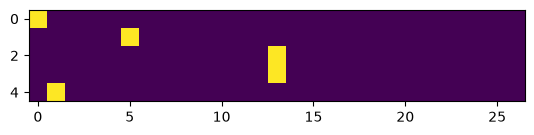

In [1072]:
plt.imshow(xenc)

In [1073]:
xenc.dtype

torch.float32

### Constructing first neuron

In [1074]:
g = torch.Generator().manual_seed(2147483647) # Create a random number generator with a fixed seed for reproducibility
W = torch.randn((27, 27), generator=g, requires_grad=True) # Initialize a weight matrix with random values for the linear transformation from input to output

xenc @ W # Perform a matrix multiplication between the one-hot encoded input and the weight matrix to get the logits for each output character

tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9643e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01,
         -4.7125e-01,  7.8682e-01, -3.2843e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4039e-01,
          9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0730e-02,
          2.4968e+00,  2.4448e+00],
        [ 4.7236e-01,  1.4830e+00,  3.1748e-01,  1.0588e+00,  2.3982e+00,
          4.6827e-01, -6.5650e-01,  6.1662e-01, -6.2197e-01,  5.1007e-01,
          1.3563e+00,  2.3445e-01, -4.5585e-01, -1.3132e-03, -5.1161e-01,
          5.5570e-01,  4.7458e-01, -1.3867e+00,  1.6229e+00,  1.7197e-01,
          9.8846e-01,  5.0657e-01,  1.0198e+00, -1.9062e+00, -4.2753e-01,
         -2.1259e+00,  9.6041e-01],
        [ 1.9359e-01,  1.0532e+00,  6.3393e-01,  2.5786e-01,  9.6408e-01,
         -2.4855e-01,  2.4756e-02, -3.0404e-02,  1.5622e+00, -4.4852e-01,
         -1.2345e+00,  1.1220e+00, -6.73

In [1075]:
# (5,27) @ (27,27) -> (5,27)
(xenc @ W).shape

torch.Size([5, 27])

### Why Do We Exponentiate the Logits: `(xenc @ W).exp()`?

* Logits are the raw, unnormalized scores produced by a model before they are converted into probabilities using softmax.

When we compute `logits = xenc @ W`, the resulting values are arbitrary real numbers (positive, negative, or zero). We want these outputs to represent a probability distribution over the next possible characters, but raw logits cannot be used directly as probabilities or counts for two main reasons.

---

### 1. The Core Problem: Negative Numbers

Probabilities and counts can never be negative:
* A probability must be in the range $[0, 1]$.
* A count must be $\ge 0$.

Because weights ($W$) are initialized randomly and updated with gradients, `xenc @ W` inevitably produces negative values. If we try to normalize negative numbers into probabilities (e.g., dividing by their sum), the math breaks down:

```python
# Suppose logits for 3 classes are:
logits = torch.tensor([-2.0, 1.0, 3.0])

# Direct normalization fails:
logits.sum() # -2.0 + 1.0 + 3.0 = 2.0
logits / logits.sum() # [-1.0, 0.5, 1.5] -> Negative probability (-1.0) and >1 probability (1.5)!
```

---

### 2. The Solution: Exponentiation ($e^x$)

The exponential function ($y = e^x$) maps any real number from $(-\infty, +\infty)$ strictly to positive values $(0, +\infty)$:

* If $x$ is large and positive, $e^x$ is a large positive number.
* If $x = 0$, $e^0 = 1$.
* If $x$ is negative, $e^x$ approaches zero, but **remains strictly positive** (e.g., $e^{-2} \approx 0.1353$).

By calculating `counts = (xenc @ W).exp()`, we guarantee that:
1. **All values are strictly positive ($> 0$):** No negative counts or invalid probabilities.
2. **Monotonicity is preserved:** If logit $A > B$, then $e^A > e^B$. The ranking of predictions does not change.

---

### 3. Interpreting Logits as "Log-Counts"

In our previous statistical bigram model, we maintained a count matrix $N$ where each cell represented how many times a character pair appeared:
$$\text{Probabilities} = \frac{\text{Counts}}{\sum \text{Counts}}$$

In the neural network setup, the raw linear outputs `xenc @ W` are treated as **log-counts** (the natural logarithm of artificial counts):
$$\text{logits} \approx \log(\text{counts})$$

To retrieve the positive, unnormalized "counts" from log-counts, we take the inverse operation of the logarithm, which is exponentiation:
$$\text{counts} = e^{\text{logits}} = e^{\log(\text{counts})}$$

---

### The Big Picture: Building the Softmax Function

Exponentiation is the first half of the **Softmax** activation function:

1. **Exponentiate (Make positive counts):**
   ```python
   counts = (xenc @ W).exp()
   ```
2. **Normalize (Divide by row sum to get probabilities summing to 1):**
   ```python
   probs = counts / counts.sum(1, keepdims=True)
   ```

Together, these two steps form the classic **Softmax** operation:
$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

* Softmax converts the model’s raw outputs (logits) into values between 0 and 1 that form a probability distribution summing to 1.

### Forward Pass

In [1076]:
# Forward pass through the model to compute the probabilities of each output character given the input characters

xenc = F.one_hot(xs, num_classes=27).float() # Convert the input indices to one-hot encoded vectors with 27 classes (26 letters + 1 for start/end tokens) & cast to float for further computations
logits = xenc @ W # Log counts / for each output character given the input characters, obtained by multiplying the one-hot encoded input with the weight matrix W.
counts = logits.exp() # Equivelent to N / The number of times each output character appears given the input characters. Convert the log counts to counts by exponentiating the logits
probs = counts / counts.sum(1, keepdim=True) # Equivelent to P / The probabilities of each output character given the input characters. Normalize the counts to get probabilities for each row
# btw : the last two lines are called "softmax" and are equivalent to the following:
#              probs = F.softmax(logits, dim=1)

In [1077]:
probs.shape

torch.Size([5, 27])

In [1078]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
       grad_fn=<SelectBackward0>)
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
       grad_fn=<SelectBackward0>)
label (actual next character):

### Loss Function

In [1079]:
loss = -probs[torch.arange(5), ys].log().mean() # Compute the average negative log likelihood (loss) for the batch of bigrams
loss

tensor(3.7693, grad_fn=<NegBackward0>)

### Backward Pass

In [1080]:
W.grad = None # Clear the gradients of the weight matrix W before backpropagation
loss.backward() # Perform backpropagation to compute the gradients of the loss with respect to the weight matrix W

### Update the gradients

In [1081]:
W.data += -0.1 * W.grad # Update the weight matrix W using gradient descent with a learning rate of 0.1

## Back from scratch

In [1082]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [1083]:
# gradient descent
for k in range(100):

  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

  # compute the loss
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean() # add L2 regularization term to the loss
  print(loss.item())

  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()

  # update
  W.data += -50 * W.grad

3.7686190605163574
3.3788068294525146
3.161090850830078
3.027186155319214
2.9344842433929443
2.8672313690185547
2.816654682159424
2.777146577835083
2.745253801345825
2.7188303470611572
2.696505546569824
2.6773719787597656
2.6608052253723145
2.6463515758514404
2.633665084838867
2.622471570968628
2.6125476360321045
2.6037068367004395
2.595794916152954
2.5886809825897217
2.5822560787200928
2.5764293670654297
2.5711238384246826
2.566272735595703
2.5618226528167725
2.5577263832092285
2.5539445877075195
2.550442695617676
2.5471925735473633
2.5441696643829346
2.5413525104522705
2.538721799850464
2.536262035369873
2.5339581966400146
2.531797409057617
2.5297679901123047
2.527860164642334
2.5260636806488037
2.5243709087371826
2.522773265838623
2.521263837814331
2.519836664199829
2.5184857845306396
2.517204999923706
2.515990734100342
2.5148372650146484
2.5137410163879395
2.512697696685791
2.511704444885254
2.5107579231262207
2.509854793548584
2.5089924335479736
2.5081686973571777
2.50738048553466

## L2 Regularization and Its Connection to Laplace Smoothing

In machine learning, we constantly fight against **overfitting**—the model becoming too confident about the training data and failing to generalize. We solve this using smoothing techniques. Surprisingly, neural networks and statistical models use different mechanisms to achieve the exact same mathematical goal.

### What is L2 Regularization?

The term `0.01 * (W**2).mean()` is an **L2 Regularization** (or Weight Decay) penalty added directly to the loss function. 
*   **The Mechanism:** It squares all the weights in the matrix $W$, calculates their average, and adds this positive number to the total loss.
*   **The Effect:** Because the optimizer's goal is to minimize the total loss, it is now forced to keep the weights ($W$) as close to $0$ as possible.
*   **The Penalty:** If the network tries to assign extremely large weights to push a probability closer to $1.0$, the $(W^2)$ penalty explodes, increasing the loss and forcing the network to back down. 

### How it Connects to Laplace Smoothing (N+1)

In our statistical bigram model, we used **Laplace Smoothing** by adding fake counts to our matrix before normalizing: `P = (N+1).float()`. 
*   We added $1$ to every single count to prevent zero probabilities.
*   This "flattens" the probability distribution, pulling it slightly closer to a uniform distribution (where every outcome is equally likely).

In a Neural Network, we do not have a count matrix $N$ to add $1$ to. Instead, we have a weight matrix $W$. **L2 Regularization is the neural network equivalent of Laplace Smoothing.** Here is the mathematical proof of why:

### The Mathematical Equivalence (The Uniform Prior)

*   Imagine the L2 penalty is so strong that it forces all weights in the matrix $W$ to be exactly $0$.
*   If $W = 0$, then computing the logits (`xenc @ W`) will output exactly $0$ for every single class.
*   When we exponentiate these logits to get our fake counts (`logits.exp()`), we calculate $e^0$.
*   Since $e^0 = 1$, the network mathematically outputs a count of $1$ for every single possible next character.
*   This is the exact equivalent of initializing an empty count matrix with $1$s.

### The Unified Concept

Both techniques inject a **Uniform Prior** into the model:
*   **Statistical Model:** "I will add $1$ to all counts so the model assumes everything is uniformly possible until proven otherwise by the data."
*   **Neural Network:** "I will pull all weights toward $0$ (which mathematically produces counts of $1$) so the network outputs a uniform probability distribution unless the training data strongly justifies larger weights."

By tuning the `0.01` hyperparameter, we control the strength of this smoothing, just like we could choose to add $0.1$, $1$, or $100$ to our statistical counts.

In [1084]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  
  out = []
  ix = 0
  while True:

    # In Statistical Modeling
    # ----------
    # BEFORE:
    # p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


# 5. İnternetten bir Türkçe isim listesi bul ve iki modeli de bu veriyle tekrar koştur. Alfabeyi Türkçe karakterlerle genişlet (ç, ğ, ı, ö, ş, ü). Modelin ürettiği isimlerden örnekleri ve loss'u göster.

## 5.1 Statistical Bigram Model

In [1085]:
tr_names = open("isimler.txt", encoding="utf-8").read().splitlines() # Read the names from the file and split them into a list with UTF-8 encoding to handle special characters

In [1086]:
N = torch.zeros((31, 31), dtype=torch.int32) # Initialize a 31x31 matrix to store bigram counts (29 letters + 1 for space + 1 for start/end tokens)

In [1087]:
# Create a lookup table to map characters to indices (0-29 for 'a'-'z', 30 for start/end tokens)
chars = sorted(list(set(''.join(tr_names)))) # Create a sorted list of unique characters in the words
stoi = {s:i+1 for i,s in enumerate(chars)} # Create a dictionary to map characters to their corresponding indices
stoi['.'] = 0 # Add a mapping for the start/end token to index 0
itos = {i:s for s,i in stoi.items()} # Create a reverse lookup table to map indices back to characters

In [1088]:
stoi

{' ': 1,
 'A': 2,
 'B': 3,
 'C': 4,
 'D': 5,
 'E': 6,
 'F': 7,
 'G': 8,
 'H': 9,
 'I': 10,
 'J': 11,
 'K': 12,
 'L': 13,
 'M': 14,
 'N': 15,
 'O': 16,
 'P': 17,
 'R': 18,
 'S': 19,
 'T': 20,
 'U': 21,
 'V': 22,
 'Y': 23,
 'Z': 24,
 'Ç': 25,
 'Ö': 26,
 'Ü': 27,
 'Ğ': 28,
 'İ': 29,
 'Ş': 30,
 '.': 0}

In [1089]:
len(stoi) # Check the length of the stoi dictionary to see how many unique characters are present in the names

31

In [1090]:
itos

{1: ' ',
 2: 'A',
 3: 'B',
 4: 'C',
 5: 'D',
 6: 'E',
 7: 'F',
 8: 'G',
 9: 'H',
 10: 'I',
 11: 'J',
 12: 'K',
 13: 'L',
 14: 'M',
 15: 'N',
 16: 'O',
 17: 'P',
 18: 'R',
 19: 'S',
 20: 'T',
 21: 'U',
 22: 'V',
 23: 'Y',
 24: 'Z',
 25: 'Ç',
 26: 'Ö',
 27: 'Ü',
 28: 'Ğ',
 29: 'İ',
 30: 'Ş',
 0: '.'}

In [1091]:
for w in tr_names:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] # Get the index of the first character in the bigram
        ix2 = stoi[ch2] # Get the index of the second character in the bigram
        N[ix1, ix2] += 1 # Increment the count of the bigram in the matrix

### 5.1.1 Virtualization (Counts array of entire dataset)

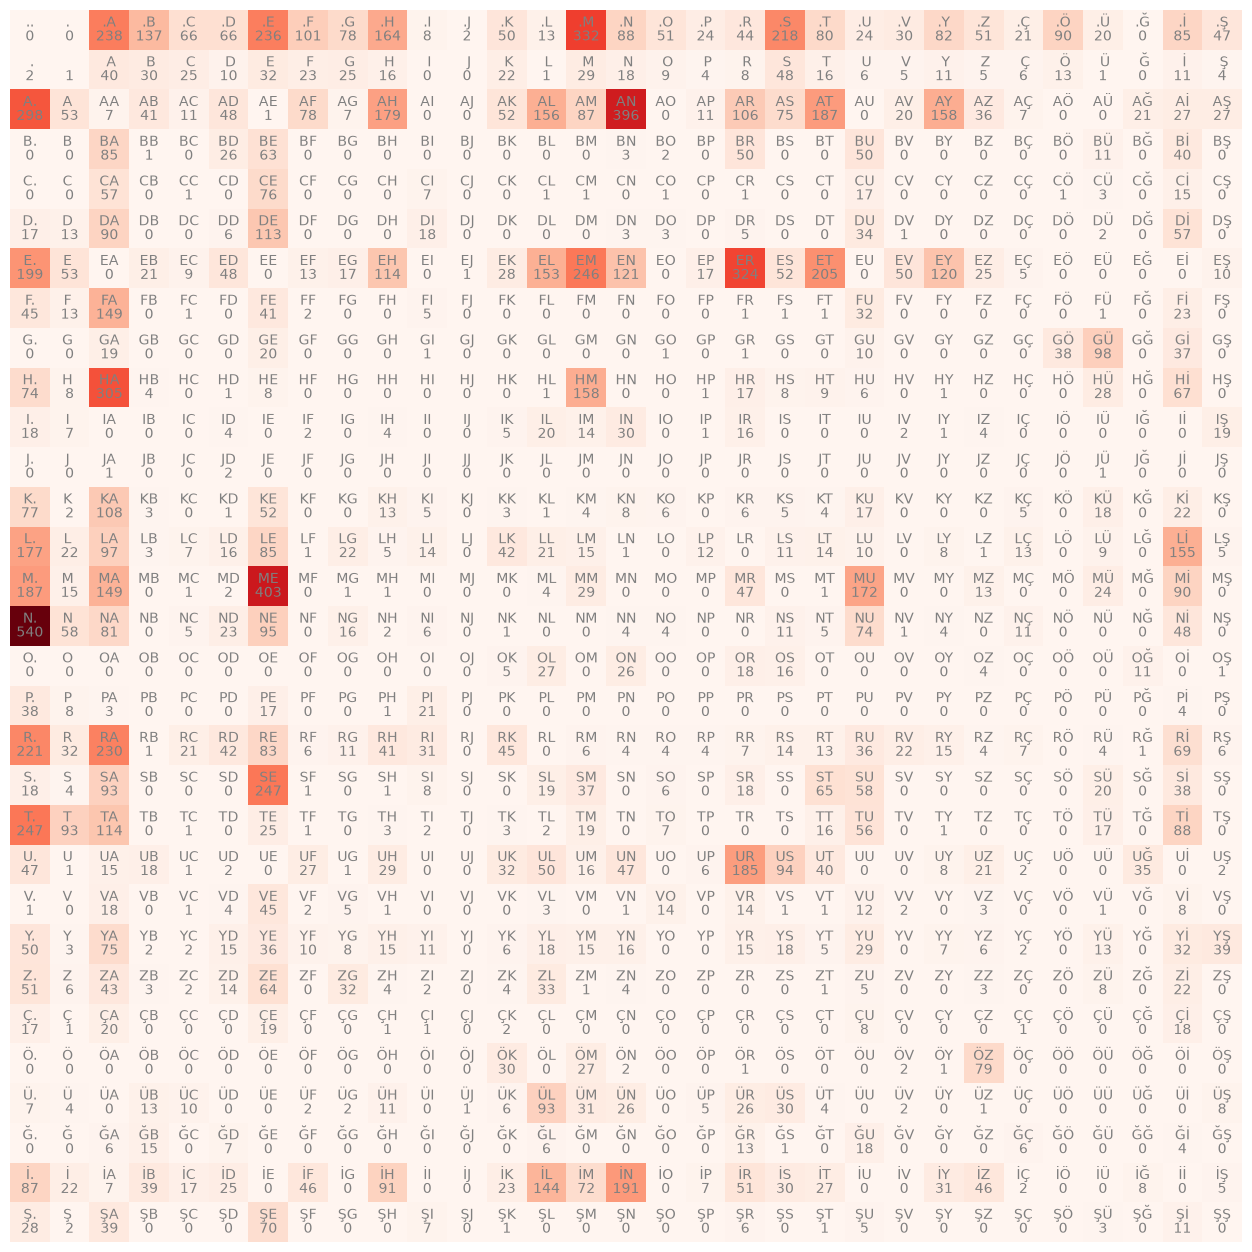

In [1092]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Reds')
for i in range(31):
    for j in range(31):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [1093]:
P = (N+1).float() # Convert the counts to float for probability calculations AND add 1 to each count for Laplace smoothing (to avoid zero probabilities for unseen bigrams)
P /= P.sum(1, keepdim=True) # Normalize the counts to get probabilities for each row

In [1094]:
P[0].sum()

tensor(1.)

### 5.1.2 Generate Names with statistical learning

In [1095]:
ix = 0
g = torch.Generator().manual_seed(2147483647)

for i in range(30):
    out = []
    while True:

        p = P[ix]

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

BURAN.
H.
FA.
AN.
MA EP.
MAŞEN.
ZEMERARH.
ER.
SETULİNE.
BAHAT.
AHİK.
BR.
ÇİNCE.
YDULAMHATU.
TUNETMERE.
SET.
MZGE.
SE MRCİT.
A.
TM.
AŞABAMURKERULAT.
BİRAYGÜLAKARANEMUA.
MATİZER.
Ç CİLL.
EYZUNUAYFAHMİRSA.
T.
FALIN.
TİN.
ÖZİZİNDE.
ÜL.


### 5.1.3 Negative log-likelihood

In [1096]:
log_likelihood = 0.0
n = 0;

for w in tr_names:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f"{ch1}{ch2}: {prob:.4f} ({logprob:.4f})")
print(f"Log-likelihood: {log_likelihood:.4f}")
nll = -log_likelihood
print(f"Negative Log-likelihood: {nll:.4f}")
print(f"Number of tokens: {n}")
print(f"Average negative log-likelihood: {nll/n:.4f}") # our loss function is the Average negative log-likelihood, which we want to minimize during training (0--to--infinity)

Log-likelihood: -43048.0273
Negative Log-likelihood: 43048.0273
Number of tokens: 18108
Average negative log-likelihood: 2.3773


## 5.2 ANN Bigram Model